In [37]:
# Depencdencies

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from tensorflow.keras.layers import TextVectorization

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM , Dropout , Bidirectional ,Dense , Embedding

from tensorflow.keras.metrics import Precision, Recall, CategoricalAccuracy

In [3]:
df = pd.read_csv('DataSource/train.csv')
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
df.iloc[5]['comment_text']

'"\n\nCongratulations from me as well, use the tools well. \xa0· talk "'

#### Text Preprocessing And Data Preparation

In [5]:
# Seperate the data into indipendent & dependent variable

x = df['comment_text']
y = df[df.columns[2:]].values

In [6]:
MaxFeatures = 20000
vectorizer = TextVectorization(
    max_tokens=MaxFeatures,
    output_sequence_length=2000,
    output_mode='int'
)
vectorizer.adapt(x.values)

In [7]:
vectorizer.get_vocabulary()

['',
 '[UNK]',
 np.str_('the'),
 np.str_('to'),
 np.str_('of'),
 np.str_('and'),
 np.str_('a'),
 np.str_('you'),
 np.str_('i'),
 np.str_('is'),
 np.str_('that'),
 np.str_('in'),
 np.str_('it'),
 np.str_('for'),
 np.str_('this'),
 np.str_('not'),
 np.str_('on'),
 np.str_('be'),
 np.str_('as'),
 np.str_('have'),
 np.str_('are'),
 np.str_('your'),
 np.str_('with'),
 np.str_('if'),
 np.str_('article'),
 np.str_('was'),
 np.str_('or'),
 np.str_('but'),
 np.str_('page'),
 np.str_('my'),
 np.str_('an'),
 np.str_('from'),
 np.str_('by'),
 np.str_('do'),
 np.str_('at'),
 np.str_('about'),
 np.str_('me'),
 np.str_('so'),
 np.str_('wikipedia'),
 np.str_('can'),
 np.str_('what'),
 np.str_('there'),
 np.str_('all'),
 np.str_('has'),
 np.str_('will'),
 np.str_('talk'),
 np.str_('please'),
 np.str_('would'),
 np.str_('its'),
 np.str_('no'),
 np.str_('one'),
 np.str_('just'),
 np.str_('like'),
 np.str_('they'),
 np.str_('he'),
 np.str_('dont'),
 np.str_('which'),
 np.str_('any'),
 np.str_('been'),
 np

In [8]:
vectorizedComments = vectorizer(x.values)

In [9]:
vectorizedComments

<tf.Tensor: shape=(159571, 2000), dtype=int64, numpy=
array([[ 645,   76,    2, ...,    0,    0,    0],
       [   1,   54, 2489, ...,    0,    0,    0],
       [ 425,  441,   70, ...,    0,    0,    0],
       ...,
       [   1, 7392,  383, ...,    0,    0,    0],
       [   5,   12,  534, ...,    0,    0,    0],
       [   5,    8,  130, ...,    0,    0,    0]], shape=(159571, 2000))>

In [10]:
dataset = tf.data.Dataset.from_tensor_slices((vectorizedComments,y))
dataset = dataset.cache()
dataset = dataset.shuffle(160000)
dataset = dataset.batch(16)
dataset = dataset.prefetch(8)

In [11]:
print(type(dataset))
batchX , batchY = dataset.as_numpy_iterator().next()
print(len(batchX),len(batchY),len(dataset)) # dataset divided into 16 row batches

<class 'tensorflow.python.data.ops.prefetch_op._PrefetchDataset'>
16 16 9974


In [12]:
train = dataset.take(int(0.7*len(dataset))) # taking the 70% batches from the dataset each batch contain 16 rows
val = dataset.skip(int(0.7*len(dataset))).take(int(0.2*len(dataset)))
test = dataset.skip(int(0.9*len(dataset))).take(int(0.1*len(dataset)))

In [13]:
train.as_numpy_iterator().next()

(array([[  51,  298,   29, ...,    0,    0,    0],
        [   1,   11,   24, ...,    0,    0,    0],
        [ 248,  111,    4, ...,    0,    0,    0],
        ...,
        [ 762,    1,    1, ...,    0,    0,    0],
        [ 139,    7, 1079, ...,    0,    0,    0],
        [9981, 7171,    8, ...,    0,    0,    0]], shape=(16, 2000)),
 array([[1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 1, 1],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 1, 1],
        [1, 1, 1, 0, 1, 0],
        [0, 0, 0, 0, 0, 0]]))

#### Creating The Model

In [17]:
model = Sequential()
model.add(Embedding(MaxFeatures+1, 32)) # word embedding layer with 32 dim
model.add(Bidirectional(LSTM(32,activation='tanh'))) # bidirectional LSTM

# adding Fully connected Dense layer
model.add(Dense(128,activation='relu'))
model.add(Dense(256,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(6,activation='sigmoid')) # six final output , sigmoid bcz 6 values between 0 to 1

model.compile(loss='binary_crossentropy',optimizer='adam') # this not categorical classification model it's binary classification model with 6 values



In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(train,epochs=1,validation_data=val)

6981/6981 ━━━━━━━━━━━━━━━━━━━━ 2427s 347ms/step - loss: 0.0631 - val_loss: 0.0482


<Figure size 1000x700 with 0 Axes>

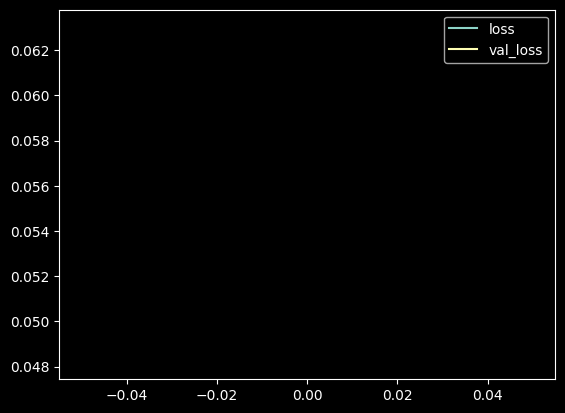

In [20]:
plt.figure(figsize = (10,7))
pd.DataFrame(history.history).plot()
plt.show()

#### Make Predictions

In [23]:
inputText = vectorizer('your freaking suck !')
print(inputText)

tf.Tensor([  21 7158  397 ...    0    0    0], shape=(2000,), dtype=int64)


In [27]:
print(df.columns[2:])
model.predict(np.array([inputText]))

Index(['toxic', 'severe_toxic', 'obscene', 'threat', 'insult',
       'identity_hate'],
      dtype='str')
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


array([[0.997377  , 0.34482288, 0.9663941 , 0.02630689, 0.86755574,
        0.1663727 ]], dtype=float32)

In [31]:
batchX , batchY = test.as_numpy_iterator().next()

In [36]:
(model.predict(batchX) > 0.5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


array([[False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [ True, False,  True, False,  True, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False],
       [ True, False,  True, False,  True, False],
       [False, False, False, False, False, False],
       [False, False, False, False, False, False]])

#### Model Evaluation

In [38]:
pre = Precision()
re = Recall()
acc = CategoricalAccuracy()

In [41]:
for batch in test.as_numpy_iterator():
    XTrue , YTrue = batch
    YHat = model.predict(XTrue)

    YTrue = YTrue.flatten()
    YHat = YHat.flatten()

    # Updating Values IN Each Iteration
    pre.update_state(YTrue , YHat)
    re.update_state(YTrue , YHat)
    acc.update_state(YTrue , YHat)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━

In [42]:
print(f'Precision: {pre.result().numpy()}, Recall: {re.result().numpy()}, Accuracy: {acc.result().numpy()}')

Precision: 0.832431435585022, Recall: 0.6465217471122742, Accuracy: 0.46238717436790466


In [43]:
model.save('CommentToxicity.h5')

In [44]:
model  = tf.keras.models.load_model('CommentToxicity.h5')

In [54]:
inputText = vectorizer('i am going to kill dammit this is strict warn')

In [55]:
model.predict(np.array([inputText]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


array([[0.71703345, 0.00725282, 0.28213423, 0.0119027 , 0.2702517 ,
        0.02189227]], dtype=float32)

In [56]:
df.columns[2:]

Index(['toxic', 'severe_toxic', 'obscene', 'threat', 'insult',
       'identity_hate'],
      dtype='str')

#### Building an Interface

In [99]:
import gradio as gr

In [100]:
model = tf.keras.models.load_model('CommentToxicity.h5')

In [105]:
def scoreComment(comment):
    VectorizedComment = vectorizer(comment)
    results = model.predict(np.array([VectorizedComment]))

    text = ''
    for idx,col in enumerate(df.columns[2:]):
        text += '{} : {} \n '.format(col,results[0][idx]>0.5)

    return text

In [106]:
scoreComment('this is very bad person')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


'toxic : False \n severe_toxic : False \n obscene : False \n threat : False \n insult : False \n identity_hate : False \n '

In [107]:
interface = gr.Interface(
    fn=scoreComment,
    inputs=gr.Textbox(
        lines=2,
        placeholder="Comment to Score"
    ),
    outputs="text"
)

In [108]:
interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://e7bddd005ef6c567fa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
